In [2]:
# extracting the zip file contents
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [3]:
# checking what folders are extracted
import os

print(os.listdir('/content/'))

['.config', 'seg_test', 'archive.zip', 'seg_pred', 'seg_train', 'sample_data']


In [4]:
train_path = "/content/seg_train/seg_train"
test_path = "/content/seg_test/seg_test"

In [5]:
# checking class folders inside training data
print(os.listdir(train_path))

['glacier', 'sea', 'mountain', 'buildings', 'street', 'forest']


In [31]:
#TASK 1
import random
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# original dataset paths
train_path_original = "/content/seg_train/seg_train"
test_path = "/content/seg_test/seg_test"

# creating smaller dataset
small_train_path = "/content/small_train"

if not os.path.exists(small_train_path):
    os.makedirs(small_train_path)

# copying limited images per class
for cls in os.listdir(train_path_original):

    original_class_path = os.path.join(train_path_original, cls)
    new_class_path = os.path.join(small_train_path, cls)

    if not os.path.exists(new_class_path):
        os.makedirs(new_class_path)

    images = os.listdir(original_class_path)

    # safe sampling
    sampled_images = random.sample(images, min(500, len(images)))

    for img in sampled_images:
        shutil.copy(
            os.path.join(original_class_path, img),
            os.path.join(new_class_path, img)
        )

print("Downsampling done")

# using reduced dataset
train_path = small_train_path

# checking counts
for cls in os.listdir(train_path):
    print(cls, len(os.listdir(os.path.join(train_path, cls))))

# resizing images
img_size = (100, 100)
batch_size = 32

# preparing data
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Downsampling done
glacier 898
sea 886
mountain 911
buildings 896
street 877
forest 891
Found 4289 images belonging to 6 classes.
Found 1070 images belonging to 6 classes.


ANS 1: In satellite images, lighting can change how things look, so the same place may look different in bright or dark conditions. Different angles or viewpoints can also change how objects appear. Also, if some classes have more images than others, the model may learn those better and make mistakes on smaller classes

In [32]:
#TASK 2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# applying augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_data = val_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 4289 images belonging to 6 classes.
Found 1070 images belonging to 6 classes.


ANS 2: Data augmentation creates different versions of the same images, like flipping or rotating them. This helps the model learn better and not just remember the training images. So it reduces overfitting and improves performance on new data.

In [33]:
#TASK 3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# building CNN model
model = Sequential()

# first layer to take image input
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)))
model.add(MaxPooling2D(2,2))

# second convolution layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# converting to vector
model.add(Flatten())

# dense layer
model.add(Dense(128, activation='relu'))

# output layer
model.add(Dense(len(train_data.class_indices), activation='softmax'))

# compiling model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# training
history = model.fit(train_data, validation_data=val_data, epochs=2)


Epoch 1/2
135/135 ━━━━━━━━━━━━━━━━━━━━ 99s 709ms/step - accuracy: 0.5094 - loss: 1.2581 - val_accuracy: 0.6374 - val_loss: 1.0022
Epoch 2/2
135/135 ━━━━━━━━━━━━━━━━━━━━ 86s 637ms/step - accuracy: 0.6029 - loss: 1.0286 - val_accuracy: 0.6701 - val_loss: 0.8909


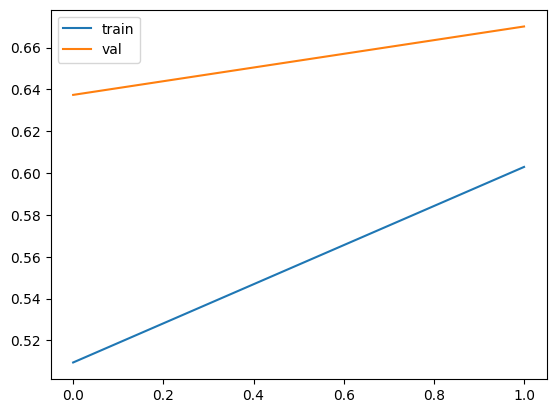

In [34]:
#plotting graph
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()


ANS 3: Convolution finds important features like edges and patterns in images. Pooling reduces the size of the image data and keeps only the important parts. Together, they help the model understand images better.

In [36]:
#TASK 4
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# loading test dataset to evaluate model on unseen data
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(100,100),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# evaluating overall model performance
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

# predicting classes for test dataset
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

# getting true labels
y_true = test_data.classes

# printing performance metrics like precision, recall and f1-score
print(classification_report(y_true, y_pred_classes))

# generating confusion matrix to see class-wise errors
print(confusion_matrix(y_true, y_pred_classes))


Found 3000 images belonging to 6 classes.
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 158ms/step - accuracy: 0.6650 - loss: 0.8908
Test Accuracy: 0.6650000214576721
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step
              precision    recall  f1-score   support

           0       0.55      0.67      0.61       437
           1       0.84      0.91      0.87       474
           2       0.57      0.77      0.66       553
           3       0.70      0.57      0.63       525
           4       0.61      0.38      0.47       510
           5       0.76      0.70      0.73       501

    accuracy                           0.67      3000
   macro avg       0.67      0.67      0.66      3000
weighted avg       0.67      0.67      0.66      3000

[[292  21  27  12  21  64]
 [ 15 429   1   2   0  27]
 [ 34   5 426  45  31  12]
 [ 52   3  96 301  69   4]
 [ 53   7 183  68 195   4]
 [ 82  47  12   3   5 352]]



ANS 4: Some classes are confused because they look similar. For example, glacier and mountain both look white, and buildings and street both show city scenes. Because of this similarity, the model sometimes predicts wrong classes.

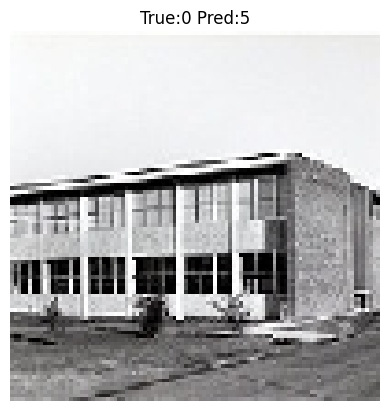

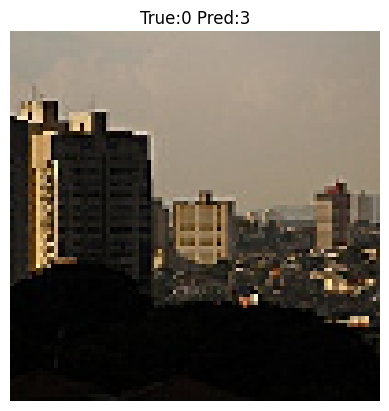

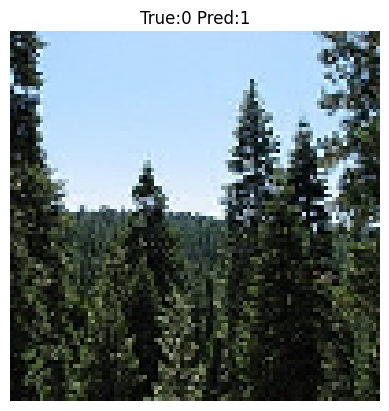

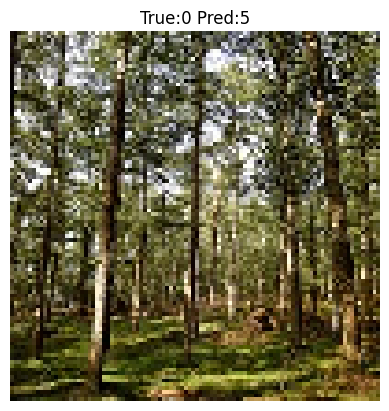

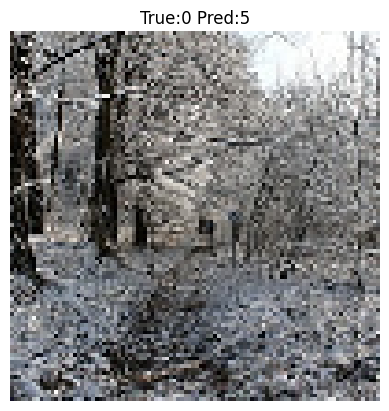

In [37]:
#TASK 5
import matplotlib.pyplot as plt
import numpy as np

# finding wrongly predicted samples
misclassified = np.where(y_pred_classes != y_true)[0]

# displaying few misclassified images to understand errors
for i in misclassified[:5]:
    img, _ = test_data[i]
    plt.imshow(img[0])
    plt.title(f"True:{y_true[i]} Pred:{y_pred_classes[i]}")
    plt.axis('off')
    plt.show()


ANS 5: Wrong predictions happen because of things like low light, fog, or unclear images. Also, when different classes look similar in color or texture, the model gets confused and makes mistakes.

In [38]:
#TASK 6
from tensorflow.keras.layers import Dropout

# rebuilding model with dropout to reduce overfitting
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

# adding dropout layer to avoid overfitting
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(len(train_data.class_indices), activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# retraining improved model
history = model.fit(train_data, validation_data=val_data, epochs=5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 92s 641ms/step - accuracy: 0.4269 - loss: 1.4392 - val_accuracy: 0.5542 - val_loss: 1.1682
Epoch 2/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 87s 643ms/step - accuracy: 0.5743 - loss: 1.1073 - val_accuracy: 0.6280 - val_loss: 0.9796
Epoch 3/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 87s 643ms/step - accuracy: 0.5987 - loss: 1.0319 - val_accuracy: 0.6327 - val_loss: 0.9456
Epoch 4/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 90s 664ms/step - accuracy: 0.6344 - loss: 0.9573 - val_accuracy: 0.6972 - val_loss: 0.8311
Epoch 5/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 85s 630ms/step - accuracy: 0.6458 - loss: 0.9307 - val_accuracy: 0.6916 - val_loss: 0.8753


ANS 6:  fter improving the model, accuracy becomes better because techniques like dropout help reduce overfitting. Also, since the dataset was reduced, the model trains faster and uses less computational resources. However, this may slightly reduce accuracy because the model is trained on fewer samples. So there is a trade-off between training speed and overall performance.

In [41]:
#saving model
model.save("scene_model.h5")

In [42]:
#dowloading model
from google.colab import files
files.download("scene_model.h5")




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ANS 7: In real-time applications, deep learning image classifiers have some limitations. They require a lot of computational power, which can make the system slow and cause delays. Also, the model may not perform well if it sees new types of images that were not present in the training data. Changes in lighting, noise, or environment can affect accuracy. In addition, updating and maintaining the model regularly can be difficult and time-consuming.